# Integrantes

Fernando de Azevedo  
RGM: 11241103994

Eliseu Portes Moura Junior   
RGM: 11241103482

Pedro Henrique Diniz Matos   
RGM: 11241103789

Rafael Pereira Do Nascimento E Silva  
RGM: 11241104274

# Análise de dados Literary Digest de 1936

Neste notebook será realizada a limpeza, preparação e análise dos dados das eleições de 1928 até 1936, com intuito de investigar a pesquisa histórica do Literary Digest e o motivo de terem errado sua previsão.

# ETAPA 1 — Limpeza e Preparação de Dados

Vão ser importados e organizados os dados das eleições. Esse processo começa com o carregamento de planilhas, renomeação de colunas e verificação de valores nulos/colunas vazias e identificação de valores falsos.

O ano de 1936 contém os dados da pesquisa Literary Digest que será analisado e comparado com o resultado real das eleições.


1.1 Bibliotecas


In [ ]:
# pandas pra mexer nas tabelas, numpy pros cálculos
import pandas as pd
import numpy as np

# matplotlib e seaborn pra gráfico
import matplotlib.pyplot as plt
import seaborn as sns

# pra não cortar coluna no display
pd.set_option('display.max_columns', None)

print("bibliotecas funcionado")


bibliotecas funcionado


Pandas e numpy são usados em tabelas e contas, matplotlib e seaborn para os gráficos. O set_option é por causa das 45+ colunas das abas.


1.2 Leitura do Excel


In [ ]:
# lê todas as abas de uma vez
sheets = pd.read_excel('LitDigestFull.xlsx', sheet_name=None)

# mostra o nome das abas
for nome in sheets.keys():
    print(nome)

df1928 = sheets['1928'].copy()
df1932 = sheets['1932'].copy()
df1936 = sheets['1936'].copy()

1924
1928
1932
1936


Carregar tudo de uma vez evita abrir e fechar arquivo várias vezes.


1.3 Inspeção inicial

In [ ]:
# dimensão de cada aba
for nome, df in sheets.items():
    print(f"{nome}: {df.shape[0]} linhas x {df.shape[1]} colunas")

# tipos de dado das abas que interessam
print("\nTipos - 1928")
print(sheets['1928'].dtypes.value_counts())
print("\nTipos - 1932")
print(sheets['1932'].dtypes.value_counts())
print("\nTipos - 1936")
print(sheets['1936'].dtypes.value_counts())

# ausentes
print("\nAusentes 1928:", sheets['1928'].isna().sum().sum())
print("Ausentes 1932:", sheets['1932'].isna().sum().sum())
print("Ausentes 1936:", sheets['1936'].isna().sum().sum())

# duplicadas
print("\nDuplicadas 1928:", sheets['1928'].duplicated().sum())
print("Duplicadas 1932:", sheets['1932'].duplicated().sum())
print("Duplicadas 1936:", sheets['1936'].duplicated().sum())


1924: 51 linhas x 46 colunas
1928: 52 linhas x 47 colunas
1932: 52 linhas x 45 colunas
1936: 51 linhas x 56 colunas

Tipos - 1928
object     35
float64    12
Name: count, dtype: int64

Tipos - 1932
object     28
float64    17
Name: count, dtype: int64

Tipos - 1936
object     44
float64    12
Name: count, dtype: int64

Ausentes 1928: 325
Ausentes 1932: 469
Ausentes 1936: 296

Duplicadas 1928: 0
Duplicadas 1932: 0
Duplicadas 1936: 0


Verificação da estrutura dos dados presentes nas bases e quantos desses dados terão de ser limpados, como por exemplos grande parte desses dados ausentes são de colunas vazias que devem ser removidas.

1.4 Estatísticas descritivas brutas







In [ ]:
# resumo das colunas numéricas de 1932
sheets['1932'].describe().round(2).iloc[:]

# mesmo pra 1936
sheets['1936'].describe().round(2).iloc[:]

,Unnamed: 9,Unnamed: 17,Unnamed: 25,Unnamed: 33,Electoral votes,Roosevelt,%,Landon,%.1,Margin,%.5,Total votes
count,0.0,0.0,0.0,0.0,49.00,49.00,49.00,49.00,49.00,49.00,49.00,49.00
mean,NaN,NaN,NaN,NaN,21.67,1132766.06,64.65,680910.71,32.98,451868.82,31.67,1863178.94
std,NaN,NaN,NaN,NaN,74.81,3940306.57,12.57,2378895.73,11.83,1567596.42,24.27,6490006.51
min,NaN,NaN,NaN,NaN,3.00,31925.00,41.52,1646.00,1.43,-42490.00,-13.97,43848.00
25%,NaN,NaN,NaN,NaN,4.00,157318.00,56.88,64555.00,27.59,85691.00,16.40,230512.00
50%,NaN,NaN,NaN,NaN,9.00,328083.00,60.80,168823.00,36.54,158177.00,25.31,488684.00
75%,NaN,NaN,NaN,NaN,13.00,734485.00,69.34,397727.00,40.18,317061.00,40.84,1142733.00
max,NaN,NaN,NaN,NaN,531.00,27752648.00,98.57,16681862.00,56.39,11070786.00,97.15,45647699.00


Essa tabela serve para dois motivos o primeiro é a identificação de valores extremos o segundo é que podemos analisar o fato verificado na última etapa, grande parte das colunas possui nomes genéricos e não consistentes, junto disso podemos perceber o fato que muitas colunas não possuem valores numéricos, por isso mostram NaN (Not a Number).

1.5 Limpeza da aba 1928

In [ ]:
# recarrega a aba 1928 do zero e refaz a renomeação
df1928 = pd.read_excel('LitDigestFull.xlsx', sheet_name='1928')
df1928.dropna(how='all', axis=1, inplace=True)

df1928.rename(columns={
    "Unnamed: 0": "Estados",
    "Unnamed: 1": "Votos Eleitorais",
    "Hoover (R)": "Votos Candidato Republicano",
    "How the same voters voted in 1924": "Eleitor Rep-Votou em R",
    "Unnamed: 4": "Eleitor Rep-Votou em Dem",
    "Unnamed: 5": "Eleitor Rep-Votou em Soci",
    "Unnamed: 6": "Eleitor Rep-Votou em Flab",
    "Unnamed: 7": "Eleitor Rep-Votou em Proh",
    "Unnamed: 8": "Eleitor Rep-Nao votou",
    "Smith (D)": "Votos Candidato Democratico",
    "How the same voters voted in 1924.1": "Eleitor Dem-Votou em R",
    "Unnamed: 12": "Eleitor Dem-Votou em Dem",
    "Unnamed: 13": "Eleitor Dem-Votou em Soci",
    "Unnamed: 14": "Eleitor Dem-Votou em Flab",
    "Unnamed: 15": "Eleitor Dem-Votou em Proh",
    "Unnamed: 16": "Eleitor Dem-Nao votou",
    "Unnamed: 19": "Estados2",
    "VOTES FOR MINOR CANDIDATES": "Soc",
    "Unnamed: 21": "Work",
    "Unnamed: 22": "Proh",
    "Unnamed: 23": "Total",
    "State - 1928": "Estados3",
    "Electoral votes": "Votos Eleitorais1",
    "Hoover": "Votos Republicanos",
    "%": "% rep",
    "Electoral votes.1": "Votos Eleitorais Rep",
    "Smith": "Votos Democratas",
    "%.1": "% dem",
    "Electoral votes.2": "Votos Eleitorais Dem",
    "Thomas (Soc.)": "Votos Soc",
    "%.2": "% soc",
    "Electoral votes.3": "Votos Eleitorais Soc",
    "Foster (Comm.)": "Votos Comm",
    "%.3": "% Comm",
    "Electoral votes.4": "Votos Eleitorais Comm",
    "Reynolds (Soc. Lab)": "Votos Soc Lab",
    "%.4": "% soc lab",
    "Electoral votes.5": "Votos Eleitorais Soc Lab",
    "Margin": "Margem",
    "%.5": "% margem",
    "State total": "total estado",
    "State": "Estados4",
    "Unnamed: 46": "Wikipedia"
}, inplace=True)

#remove os "-" coloca o 0
df1928 = df1928.replace("-", 0).infer_objects(copy=False)

# empurra a parte colorida uma linha pra baixo
col_shift = df1928.columns[df1928.columns.get_loc("Estados3")]
df1928[col_shift] = df1928[col_shift].shift(1)

# remove o cabeçalho
df1928 = df1928[df1928["Estados"].notna()].reset_index(drop=True)

/tmp/ipykernel_3797/2669701734.py:52: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df1928 = df1928.replace("-", 0).infer_objects(copy=False)


Aqui foi renomeado as tabelas para simplificar o trabalho nelas, junto disso uma parte da tabela foi movida para baixo para remover a primeira linha dos dados, que servia como um cabeçalho e não nos entrega dados muito úteis.

Uma quantidade considerável dos dados possui "-" no lugar de espaços vazios, então substituímos esse caractere por 0 nos dados. Além de remover todas as colunas vazias/redundantes

In [ ]:
#junta partidos pequenos
df1928["Votos Outros"] = df1928[["Soc", "Work", "Proh"]].sum(axis=1, skipna=True)
df1928.drop(columns=["Soc", "Work", "Proh"], inplace=True)

#move pra ficar do lado do campo que combina
cols = df1928.columns.tolist()
cols.remove("Votos Outros")
pos = cols.index("Eleitor Dem-Nao votou") + 1
cols.insert(pos, "Votos Outros")
df1928 = df1928[cols]

# mesma coisa pra outros grupos de partido menor
df1928["Votos Outros Partidos"] = df1928[["Votos Soc", "Votos Comm", "Votos Soc Lab"]].sum(axis=1, skipna=True)
df1928.drop(columns=["Votos Soc", "Votos Comm", "Votos Soc Lab"], inplace=True)

df1928["% Outros Partidos"] = df1928[["% soc", "% Comm", "% soc lab"]].sum(axis=1, skipna=True)
df1928.drop(columns=["% soc", "% Comm", "% soc lab"], inplace=True)

df1928["Votos Eleitorais Outros"] = df1928[["Votos Eleitorais Soc", "Votos Eleitorais Comm", "Votos Eleitorais Soc Lab"]].sum(axis=1, skipna=True)
df1928.drop(columns=["Votos Eleitorais Soc", "Votos Eleitorais Comm", "Votos Eleitorais Soc Lab"], inplace=True)

#mesma coisa pro comportamento declarado
df1928["Eleitor Rep-Votou em Outro"] = df1928[["Eleitor Rep-Votou em Soci", "Eleitor Rep-Votou em Flab", "Eleitor Rep-Votou em Proh"]].sum(axis=1, skipna=True)
df1928.drop(columns=["Eleitor Rep-Votou em Soci", "Eleitor Rep-Votou em Flab", "Eleitor Rep-Votou em Proh"], inplace=True)

df1928["Eleitor Dem-Votou em Outro"] = df1928[["Eleitor Dem-Votou em Soci", "Eleitor Dem-Votou em Flab", "Eleitor Dem-Votou em Proh"]].sum(axis=1, skipna=True)
df1928.drop(columns=["Eleitor Dem-Votou em Soci", "Eleitor Dem-Votou em Flab", "Eleitor Dem-Votou em Proh"], inplace=True)

#margem e total pro fim
cols = df1928.columns.tolist()
cols.remove("total estado")
cols.remove("Margem")
cols.remove("% margem")
cols.append("Margem")
cols.append("% margem")
cols.append("total estado")
df1928 = df1928[cols]

df1928.head()


,Estados,Votos Eleitorais,Votos Candidato Republicano,Eleitor Rep-Votou em R,Eleitor Rep-Votou em Dem,Eleitor Rep-Nao votou,Votos Candidato Democratico,Eleitor Dem-Votou em R,Eleitor Dem-Votou em Dem,Eleitor Dem-Nao votou,Votos Outros,Estados2,Total,Estados3,Votos Eleitorais1,Votos Republicanos,% rep,Votos Eleitorais Rep,Votos Democratas,% dem,Votos Eleitorais Dem,Estados4,Wikipedia,Votos Outros Partidos,% Outros Partidos,Votos Eleitorais Outros,Eleitor Rep-Votou em Outro,Eleitor Dem-Votou em Outro,Margem,% margem,total estado
0,ALABAMA,12,13997,4351,7221,2373,12298,757,9604,1881,107,ALABAMA,26402,Alabama,3.0,52533.0,57.57,3.0,38537.0,42.23,0.0,AZ,https://en.wikipedia.org/wiki/1928_United_Stat...,184.0,0.20,0.0,52,56,13996.0,15.34,91254.0
1,ARIZONA,3,3371,1840,936,556,2250,593,1197,398,62,ARIZONA,5683,Arizona,9.0,77751.0,39.33,0.0,119196.0,60.29,9.0,AR,NaN,746.0,0.38,0.0,39,62,-41445.0,-20.96,197693.0
2,ARKANSAS,9,11652,4835,5107,1659,11267,963,8780,1452,133,ARKANSAS,23052,Arkansas,13.0,1162323.0,64.69,13.0,614365.0,34.19,0.0,CA,NaN,19707.0,1.10,0.0,51,72,547958.0,30.50,1796656.0
3,CALIFORNIA,13,89103,62283,10686,14539,41566,22717,9766,7502,1895,CALIFORNIA,132564,California,6.0,253872.0,64.72,6.0,133131.0,33.94,0.0,CO,NaN,4147.0,1.06,0.0,1595,1581,120741.0,30.78,392242.0
4,COLORADO,6,16800,11236,2627,2739,6779,2452,2829,1243,283,COLORADO,23862,Colorado,7.0,296614.0,53.63,7.0,252040.0,45.57,0.0,CT,NaN,4371.0,0.79,0.0,198,255,44574.0,8.06,553031.0


Para simplificar os dados originais os partidos menores que possuem pouquíssimos votos foram agrupador em “Outros”, dessa forma diminuindo a complexidade da analise sem perder informação, além disso troca a ordem das colunas para melhor visualização.


1.6 Limpeza da aba 1932


In [ ]:
df1932 = sheets['1932'].copy()
df1932.dropna(how='all', axis=1, inplace=True)

df1932.rename(columns={
    "Unnamed: 0": "Estados",
    "Unnamed: 1": "Votos Eleitorais",
    "HOOVER": "Votos Candidato Republicano",
    "How the same Voters voted in 1928": "Eleitor Rep-Votou em R",
    "Unnamed: 4": "Eleitor Rep-Votou em Dem",
    "Unnamed: 5": "Eleitor Rep-Votou em Outro",
    "Unnamed: 6": "Eleitor Rep-Nao votou",
    "ROOSEVELT": "Votos Candidato Democratico",
    "How the same Voters voted in 1928.1": "Eleitor Dem-Votou em R",
    "Unnamed: 11": "Eleitor Dem-Votou em Dem",
    "Unnamed: 12": "Eleitor Dem-Votou em Outro",
    "Unnamed: 13": "Eleitor Dem-Nao votou",
    "VOTES FOR MINOR CANDIDATES": "Soc",
    "Unnamed: 17": "Soc Lab",
    "Unnamed: 18": "Farmer Lab",
    "Unnamed: 19": "Proh",
    "Unnamed: 20": "Comm",
    "Unnamed: 21": "Misc",
    "Unnamed: 22": "Votos Outros",
    "GRAND TOTAL VOTES": "Total",
    "State - 1932": "Estados3",
    "Electoral votes": "Votos Eleitorais Total",
    "Roosevelt": "Votos Democratas",
    "%": "% dem",
    "Electoral votes.1": "Votos Eleitorais Dem",
    "Hoover": "Votos Republicanos",
    "%.1": "% rep",
    "Electoral votes.2": "Votos Eleitorais Rep",
    "Thomas (Soc.)": "Votos Soc",
    "%.2": "% soc",
    "Electoral votes.3": "Votos Eleitorais Soc",
    "Other": "Votos outros partidos",
    "%.3": "% outros",
    "Electoral votes.4": "Votos Eleitorais Outros",
    "Margin": "Margem",
    "%.4": "% margem",
    "Total votes": "total estado",
    "Unnamed: 44": "Wikipedia"
}, inplace=True)

# cuidado: aqui o traço é en dash, não hyphen
df1932.replace("–", 0, inplace=True)

# empurra parte colorida
idx = df1932.columns.get_loc("Total")
cols_to_shift = df1932.columns[idx:]
df1932[cols_to_shift] = df1932[cols_to_shift].shift(1)

df1932 = df1932[df1932["Estados"].notna()].reset_index(drop=True)

df1932.drop(columns=["Estados3", "Wikipedia", "Soc", "Soc Lab", "Farmer Lab",
                     "Proh", "Comm", "Misc"], inplace=True)

# junta socialista + outros
df1932["Votos Outros Partidos"] = df1932[["Votos Soc", "Votos outros partidos"]].sum(axis=1, skipna=True)
df1932.drop(columns=["Votos Soc", "Votos outros partidos"], inplace=True)

df1932["% Outros Partidos"] = df1932[["% soc", "% outros"]].sum(axis=1, skipna=True)
df1932.drop(columns=["% soc", "% outros"], inplace=True)

df1932["Votos Eleitorais Outros"] = df1932[["Votos Eleitorais Soc", "Votos Eleitorais Outros"]].sum(axis=1, skipna=True)
df1932.drop(columns=["Votos Eleitorais Soc"], inplace=True)

# margem e total pro fim
cols = df1932.columns.tolist()
cols.remove("total estado")
cols.remove("Margem")
cols.remove("% margem")
cols.append("Margem")
cols.append("% margem")
cols.append("total estado")
df1932 = df1932[cols]


/tmp/ipykernel_3797/4125812350.py:46: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df1932.replace("–", 0, inplace=True)


Basicamente o mesmo tratamento de dados da eleição de 1928

1.7 Limpeza da aba 1936

In [ ]:
df1936 = sheets['1936'].copy()
df1936.dropna(how='all', axis=1, inplace=True)

df1936.rename(columns={
    "Unnamed: 0": "Estados",
    "Unnamed: 1": "Votos Eleitorais",
    "Landon  (R)": "Votos Candidato Republicano",
    "How did they vote in 1932?": "Eleitor Rep-Votou em R",
    "Unnamed: 4": "Eleitor Rep-Votou em Dem",
    "Unnamed: 5": "Eleitor Rep-Votou em Soc",
    "Unnamed: 6": "Eleitor Rep-Votou em Outros",
    "Unnamed: 7": "Eleitor Rep-Nao votou",
    "Unnamed: 8": "Eleitor Rep-Voto Nao Indicado",
    "Roosevelt  (D)": "Votos Candidato Democratico",
    "How did they vote in 1932?.1": "Eleitor Dem-Votou em R",
    "Unnamed: 12": "Eleitor Dem-Votou em Dem",
    "Unnamed: 13": "Eleitor Dem-Votou em Soc",
    "Unnamed: 14": "Eleitor Dem-Votou em Outros",
    "Unnamed: 15": "Eleitor Dem-Nao votou",
    "Unnamed: 16": "Eleitor Dem-Voto Nao Indicado",
    "Lemke (Union)": "Votos Candidato Uniao",
    "How did they vote in 1932?.2": "Eleitor Uniao-Votou em R",
    "Unnamed: 20": "Eleitor Uniao-Votou em Dem",
    "Unnamed: 21": "Eleitor Uniao-Votou em Soc",
    "Unnamed: 22": "Eleitor Uniao-Votou em Outros",
    "Unnamed: 23": "Eleitor Uniao-Nao votou",
    "Unnamed: 24": "Eleitor Uniao-Voto Nao Indicado",
    "MINOR CANDIDATES": "Soc",
    "Unnamed: 27": "Comm",
    "Unnamed: 28": "Proh",
    "Unnamed: 29": "Soc Lab",
    "Unnamed: 30": "Misc",
    "Unnamed: 31": "Total",
    "Grand Total Votes": "Total Geral",
    "State - 1936": "Estados3",
    "Electoral votes": "Votos Eleitorais Total",
    "Roosevelt  ": "Votos Democratas",
    "%": "% dem",
    "Electoral votes.1": "Votos Eleitorais Dem",
    "Landon   ": "Votos Republicanos",
    "%.1": "% rep",
    "Electoral votes.2": "Votos Eleitorais Rep",
    "Lemke (Union).1": "Votos Uniao",
    "%.2": "% uniao",
    "Electoral votes.3": "Votos Eleitorais Uniao",
    "Thomas (Soc.)": "Votos Soc",
    "%.3": "% soc",
    "Electoral votes.4": "Votos Eleitorais Soc",
    "Other": "Votos Outros",
    "%.4": "% outros",
    "Electoral votes.5": "Votos Eleitorais Outros",
    "Margin": "Margem",
    "%.5": "% margem",
    "Total votes": "total estado",
    "State": "Estados4",
    "Unnamed: 55": "Wikipedia"
}, inplace=True)

# tira espaço extra dos nomes
df1936.columns = df1936.columns.str.strip()

col_shift = df1936.columns.get_loc("Estados3")
df1936.iloc[:, col_shift:] = df1936.iloc[:, col_shift:].shift(1)

# remove a linha de cabeçalho decorativo que ficou no topo depois do shift
df1936 = df1936.drop(index=0).reset_index(drop=True)

# junta socialista com outros no comportamento declarado
df1936["Eleitor Rep-Votou em Outros"] = df1936[["Eleitor Rep-Votou em Soc", "Eleitor Rep-Votou em Outros"]].sum(axis=1, skipna=True)
df1936.drop(columns=["Eleitor Rep-Votou em Soc"], inplace=True)

df1936["Eleitor Dem-Votou em Outros"] = df1936[["Eleitor Dem-Votou em Soc", "Eleitor Dem-Votou em Outros"]].sum(axis=1, skipna=True)
df1936.drop(columns=["Eleitor Dem-Votou em Soc"], inplace=True)


Algumas colunas vêm com espaços no começo ou fim "Roosevelt " foi usado o .str.strip() limpa isso.


1.8 Separação das linhas que não são estados


In [ ]:
# lista do que não é estado
nao_estados = ["TOTALS","STATE UNKNOWN","TOTALS:","totals", "totals:", "state unknown", "total"]

def tirar_linhas_especiais(df):
    df = df.copy()
    mask = df["Estados"].astype(str).str.lower().str.strip().isin(nao_estados)
    # o ~ inverte: mantém o que NÃO está na lista
    return df[~mask].reset_index(drop=True)

df1928_est = tirar_linhas_especiais(df1928)
df1932_est = tirar_linhas_especiais(df1932)
df1936_est = tirar_linhas_especiais(df1936)

print(f"1928 sem as linhas especiais: {len(df1932_est)}")
print(f"1932 sem as linhas especiais: {len(df1932_est)}")
print(f"1936 sem as linhas especiais: {len(df1936_est)}")


1928 sem as linhas especiais: 49
1932 sem as linhas especiais: 49
1936 sem as linhas especiais: 48


In [ ]:
# converte as colunas que ficaram como texto pra número
def converte_numericas(df):
    df = df.copy()
    for col in df.columns:
        # pula as colunas de texto (nome do estado)
        if col in ["Estados", "estado_join"]:
            continue
        # só tenta converter se for object (texto)
        if df[col].dtype == "object":
            df[col] = pd.to_numeric(df[col], errors="coerce")
    return df
df1928_est = converte_numericas(df1928_est)
df1932_est = converte_numericas(df1932_est)
df1936_est = converte_numericas(df1936_est)

# confere se virou número
print("Tipos 1932:")
print(df1928_est.dtypes.value_counts())
print("\nTipos 1932:")
print(df1932_est.dtypes.value_counts())
print("\nTipos 1936:")
print(df1936_est.dtypes.value_counts())

Tipos 1932:
float64    18
int64      12
object      1
Name: count, dtype: int64

Tipos 1932:
float64    14
int64      12
object      1
Name: count, dtype: int64

Tipos 1936:
int64      27
float64    22
object      1
Name: count, dtype: int64


Remove colunas irrelevantes para a análise dos dados e converte o do dataframe para tipo numérico


1.9 Comparação antes x depois


In [ ]:
print("ANTES x DEPOIS\n")
print(f"1928 antes : {sheets['1928'].shape[0]} x {sheets['1928'].shape[1]}")
print(f"1928 depois: {df1928.shape[0]} x {df1928.shape[1]}\n")
print(f"1932 antes : {sheets['1932'].shape[0]} x {sheets['1932'].shape[1]}")
print(f"1932 depois: {df1932.shape[0]} x {df1932.shape[1]}\n")
print(f"1936 antes : {sheets['1936'].shape[0]} x {sheets['1936'].shape[1]}")
print(f"1936 depois: {df1936.shape[0]} x {df1936.shape[1]}")

ANTES x DEPOIS

1928 antes : 52 x 47
1928 depois: 51 x 31

1932 antes : 52 x 45
1932 depois: 51 x 27

1936 antes : 51 x 56
1936 depois: 50 x 50


# ETAPA 2 — Análise Exploratória e Estatística Descritiva

Durante essa etapa será realizado a analise de como os dados são distribuídos e comparação entre as eleições de diferentes anos.

2.1 Proporções de cada candidato em 1936


In [ ]:
#cria uma cópia só com estados, pra trabalhar sem mexer no df original
d36 = df1936_est.copy()

#total das pessoas que responderam por estado em 1936
d36["total respostas"] = (d36["Votos Candidato Republicano"]
                     + d36["Votos Candidato Democratico"]
                     + d36["Votos Candidato Uniao"])

#proporção de cada candidato na pesquisa
d36["proporcao landon"] = d36["Votos Candidato Republicano"] / d36["total respostas"]
d36["proporcao roosevelt"] = d36["Votos Candidato Democratico"] / d36["total respostas"]
d36["proporcao lemke"] = d36["Votos Candidato Uniao"] / d36["total respostas"]

#diferença entre os dois grandes partidos
d36["diferenca landon roosevelt"] = d36["proporcao landon"] - d36["proporcao roosevelt"]

d36[["Estados", "proporcao landon", "proporcao roosevelt", "proporcao lemke", "diferenca landon roosevelt"]].head()

,Estados,proporcao landon,proporcao roosevelt,proporcao lemke,diferenca landon roosevelt
0,Alabama,0.231643,0.763210,0.005148,-0.531567
1,Arizona,0.529212,0.447237,0.023551,0.081975
2,Arkansas,0.260172,0.726648,0.013181,-0.466476
3,California,0.521236,0.449784,0.028980,0.071452
4,Colorado,0.600648,0.377547,0.021805,0.223101


Análise da proporção de votos para cada um dos três candidatos principais de 1936, verificando a diferença entre os dois grandes partidos, um número positivo de diferencia mostra vantagem para Landon um número negativo representa vantagem para o Roosevelt.

2.2 Distribuição das proporções


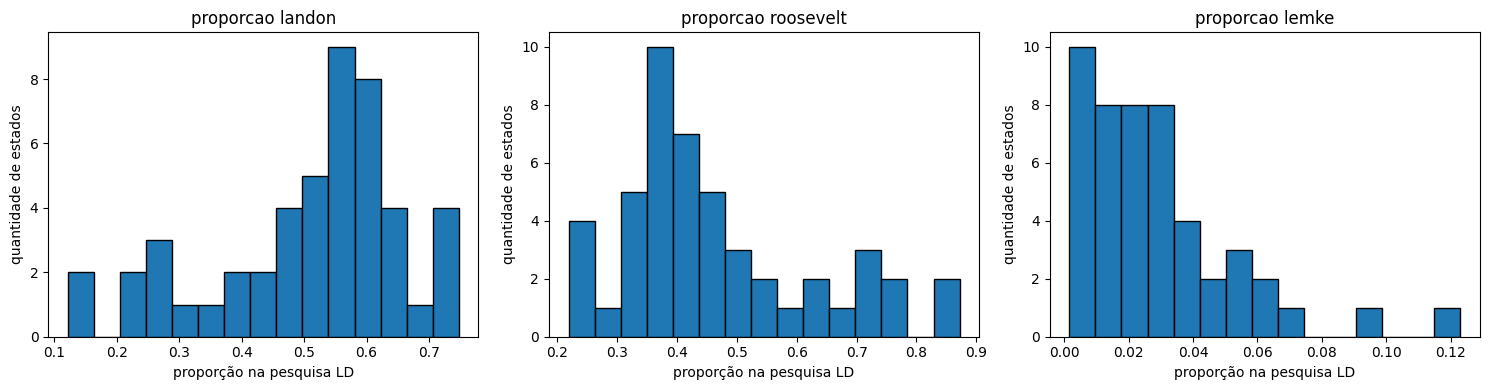

In [ ]:
d36[["proporcao landon", "proporcao roosevelt", "proporcao lemke"]].describe().round(3)

# distribuição visual
fig, ax = plt.subplots(1, 3, figsize=(15, 4))

for i, cand in enumerate(["proporcao landon", "proporcao roosevelt", "proporcao lemke"]):
    ax[i].hist(d36[cand], bins=15, edgecolor="black")
    ax[i].set_title(cand)
    ax[i].set_xlabel("proporção na pesquisa LD")
    ax[i].set_ylabel("quantidade de estados")

plt.tight_layout()
plt.show()



Esses três histogramas mostram como os estados se distribuem em relação à proporção que cada candidato tinha na pesquisa da Literary Digest de 1936. Podemos analisar que Landon tem forte pico entre 0.5 e 0.6 mostrando que as análises de Literary Digest via Landom ganhando em grande parte dos estados, quando comparado com os outros candidatos com picos entre 0.3/0.4 e 0 e 0.04

2.3 Ranking por estado


In [ ]:
# top 10 estados mais pró-Landon na pesquisa
top_landon = d36[["Estados", "proporcao landon"]].sort_values("proporcao landon", ascending=False).head(10)
print("Top 10 pró-Landon")
display(top_landon)

# top 10 mais pró-Roosevelt
top_roosevelt = d36[["Estados", "proporcao roosevelt"]].sort_values("proporcao roosevelt", ascending=False).head(10)
print("\nTop 10 pró-Roosevelt")
display(top_roosevelt)



Top 10 pró-Landon


,Estados,proporcao landon
26,New Hampshire,0.747564
18,Massachusetts,0.735923
42,Vermont,0.733414
36,Rhode Island,0.708322
16,Maine,0.671086
27,New Jersey,0.661134
5,Connecticut,0.659079
19,Michigan,0.639161
13,Kansas,0.625981
38,South Dakota,0.616497



Top 10 pró-Roosevelt


,Estados,proporcao roosevelt
21,Mississippi,0.872185
37,South Carolina,0.848662
8,Georgia,0.764292
0,Alabama,0.763210
2,Arkansas,0.726648
30,North Carolina,0.726415
40,Texas,0.702266
39,Tennessee,0.665135
15,Louisiana,0.635771
43,Virginia,0.619756


Apresenta os estados onde a Literary Digest previu maiores apoios para cada candidato, é importante perceber que Vermont é um dos estados marcados como a favor Landon, mesmo que em realidade Roosevelt tenha ganho nele, apontando para um viés nas respostas.


2.4 Comparação com o resultado real de 1936


In [ ]:
# proporção real (Wikipedia) já está em % rep_36 e % dem_36
d36["proporcao real rep"] = d36["% rep"] / 100
d36["proporcao real dem"] = d36["% dem"] / 100

# erro da LD por estado (proporção prevista - proporção real)
d36["erro representado"] = d36["proporcao landon"] - d36["proporcao real rep"]

# resumo
print("Erro médio (Landon previsto - Rep real):", round(d36["erro representado"].mean(), 4))
print("Erro mediano:", round(d36["erro representado"].median(), 4))
print("Desvio padrão do erro:", round(d36["erro representado"].std(), 4))

Erro médio (Landon previsto - Rep real): 0.1784
Erro mediano: 0.1768
Desvio padrão do erro: 0.0723


O erro médio mostra o viés sistemático. Se for positivo, a Literary Digest exagerou o republicano na maioria dos estados. O desvio padrão mostra se o erro foi uniforme ou concentrado em alguns estados específicos.


2.5 Discrepância estadual


In [ ]:
# 10 estados com maior erro absoluto
d36["erro absoluto"] = d36["erro representado"].abs()
top_erro = d36[["Estados", "proporcao landon", "proporcao real rep", "erro representado", "erro absoluto"]] \
    .sort_values("erro absoluto", ascending=False).head(10)

display(top_erro)

,Estados,proporcao landon,proporcao real rep,erro representado,erro absoluto
18,Massachusetts,0.735923,0.4176,0.318323,0.318323
36,Rhode Island,0.708322,0.4018,0.306522,0.306522
46,Wisconsin,0.580498,0.3026,0.277898,0.277898
44,Washington,0.572109,0.2988,0.273309,0.273309
26,New Hampshire,0.747564,0.4798,0.267764,0.267764
23,Montana,0.543320,0.2759,0.267420,0.267420
27,New Jersey,0.661134,0.3957,0.265434,0.265434
1,Arizona,0.529212,0.2693,0.259912,0.259912
5,Connecticut,0.659079,0.4035,0.255579,0.255579
19,Michigan,0.639161,0.3876,0.251561,0.251561


Mostra onde o erro é maior.


# ETAPA 3 — Diagnóstico de Viés



3.1 Viés de amostragem

O objetivo dessa etapa é comparar o que os respondentes disseram que votariam em 1932 com o que a população realmente votou em 1932. Se essas informações não baterem existe uma prova clara de um viés na pesquisa.


In [ ]:
# soma do que os respondentes de 1936 declararam ter feito em 1932
rep_declarou_rep = d36["Eleitor Rep-Votou em R"].sum()
rep_declarou_dem = d36["Eleitor Rep-Votou em Dem"].sum()
rep_declarou_outro = d36["Eleitor Rep-Votou em Outros"].sum()
rep_nao_votou = d36["Eleitor Rep-Nao votou"].sum()

dem_declarou_rep = d36["Eleitor Dem-Votou em R"].sum()
dem_declarou_dem = d36["Eleitor Dem-Votou em Dem"].sum()
dem_declarou_outro = d36["Eleitor Dem-Votou em Outros"].sum()
dem_nao_votou = d36["Eleitor Dem-Nao votou"].sum()

total_declarado = (rep_declarou_rep + rep_declarou_dem + rep_declarou_outro + rep_nao_votou +
                   dem_declarou_rep + dem_declarou_dem + dem_declarou_outro + dem_nao_votou)

# proporção de voto declarado em 1932 (Rep, Dem, Outro, Não votou)
composicao_amostra = {
    "Rep": (rep_declarou_rep + dem_declarou_rep) / total_declarado,
    "Dem": (rep_declarou_dem + dem_declarou_dem) / total_declarado,
    "Outro": (rep_declarou_outro + dem_declarou_outro) / total_declarado,
    "Não votou": (rep_nao_votou + dem_nao_votou) / total_declarado,
}

for k, v in composicao_amostra.items():
    print(f"{k}: {v:.2%}")


Rep: 48.98%
Dem: 44.37%
Outro: 1.18%
Não votou: 5.47%


In [ ]:
# o real de 1932 (Wikipedia, aba 1932, linha Totals)
# já tinhamos: Roosevelt 57,41%, Hoover 39,65%, outros 2,95%
composicao_real = {
    "Rep": 0.3965,
    "Dem": 0.5741,
    "Outro": 0.0295,
    "Não votou": 0.0,  # não faz sentido na eleição real
}

# comparação lado a lado
comparativo = pd.DataFrame({
    "amostra LD (declarado)": composicao_amostra,
    "real 1932": composicao_real,
})
comparativo["diferença (pp)"] = (comparativo["amostra LD (declarado)"] - comparativo["real 1932"]) * 100
display(comparativo.round(4))


,amostra LD (declarado),real 1932,diferença (pp)
Rep,0.4898,0.3965,9.3260
Dem,0.4437,0.5741,-13.0361
Outro,0.0118,0.0295,-1.7713
Não votou,0.0547,0.0000,5.4715


Aqui comparamos a amostra da pesquisa da LD com os dados reais, por volta de 50% das pessoas disseram que votariam no Hoover nas eleições de 1932, porém, apenas 39,6% tinham realmente votado, isso mostra que a amostra selecionada tem uma representação maior dos republicanos do que a realidade.

3.2 Gráfico do viés de amostragem


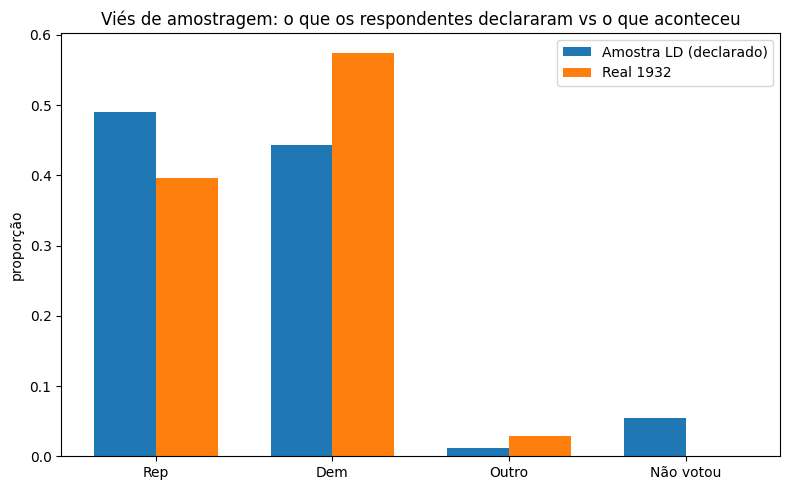

In [ ]:
fig, ax = plt.subplots(figsize=(8, 5))

categorias = list(composicao_amostra.keys())
x = np.arange(len(categorias))
larg = 0.35

ax.bar(x - larg/2, [composicao_amostra[c] for c in categorias], larg, label="Amostra LD (declarado)")
ax.bar(x + larg/2, [composicao_real[c] for c in categorias], larg, label="Real 1932")

ax.set_xticks(x)
ax.set_xticklabels(categorias)
ax.set_ylabel("proporção")
ax.set_title("Viés de amostragem: o que os respondentes declararam vs o que aconteceu")
ax.legend()

plt.tight_layout()
plt.show()


O gráfico representa o vies mencionado anteriormente.

3.3 Viés de não resposta


In [ ]:
# "não votou" e "voto não indicado" por candidato em 1936
nao_votou_total = (d36["Eleitor Rep-Nao votou"].sum() + d36["Eleitor Dem-Nao votou"].sum())
nao_indicado_total = (d36["Eleitor Rep-Voto Nao Indicado"].sum() + d36["Eleitor Dem-Voto Nao Indicado"].sum())

# total de respondentes que deram alguma informação sobre 1932
total_informacao_1932 = total_declarado + nao_indicado_total

print(f"Respondentes que disseram 'não votou em 1932': {nao_votou_total:,}")
print(f"Respondentes que 'não indicaram' o voto de 1932: {nao_indicado_total:,}")
print(f"Total de respondentes com info sobre 1932: {total_informacao_1932:,}")
print()
print(f"% que não votou em 1932: {nao_votou_total / total_informacao_1932:.2%}")
print(f"% que não indicou: {nao_indicado_total / total_informacao_1932:.2%}")


Respondentes que disseram 'não votou em 1932': 118,139
Respondentes que 'não indicaram' o voto de 1932: 93,681
Total de respondentes com info sobre 1932: 2,252,863

% que não votou em 1932: 5.24%
% que não indicou: 4.16%


As colunas medem as pessoas que responderam as pesquisas de 1936, mas não votaram em 1932, todas essas pessoas não são relevantes para a análise de candidatos já que provavelmente não vão votar de novo em 1936. Isso apresenta o viés de não resposta, ou seja, quem responde à pesquisa é diferente de quem realmente vota.

3.4 Gráfico da composição da amostra por estado


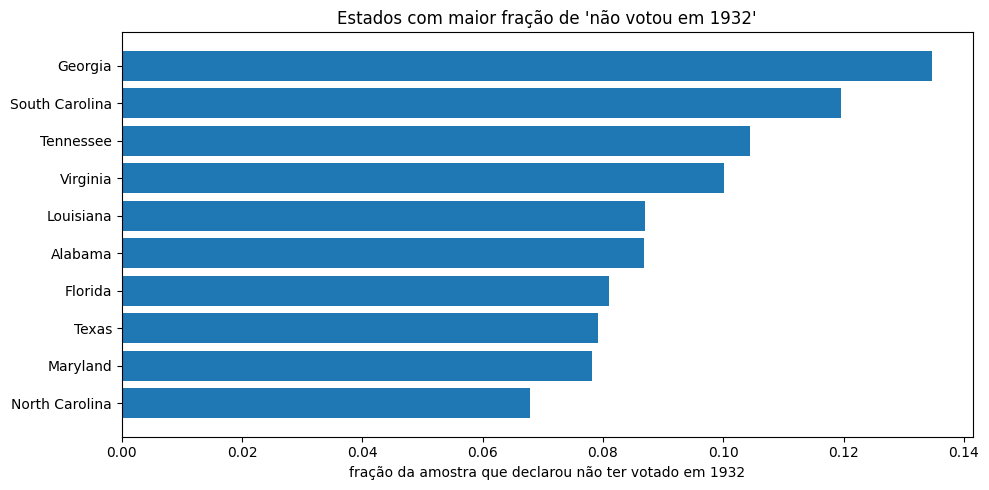

In [ ]:
# fração de "não votou em 1932" por estado
d36["frac_nao_votou_32"] = (d36["Eleitor Rep-Nao votou"] + d36["Eleitor Dem-Nao votou"]) / d36["total respostas"]

# top 10 estados com mais "não votou"
top_nao_votou = d36[["Estados", "frac_nao_votou_32"]].sort_values("frac_nao_votou_32", ascending=False).head(10)

fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(top_nao_votou["Estados"], top_nao_votou["frac_nao_votou_32"])
ax.set_xlabel("fração da amostra que declarou não ter votado em 1932")
ax.set_title("Estados com maior fração de 'não votou em 1932'")
ax.invert_yaxis()
plt.tight_layout()
plt.show()


Alguns estados tem uma fração grande de não votou, isso representa que a amostr da pesquisa possui inflação de não eleitores, dessa forma esses estados puxam a previsão da Literary Digest para longe do mundo real.

# ETAPA 4 — Modelagem Preditiva Básica



4.1 Preparação do merge


In [ ]:
#padroniza nome de estado pra conseguir comparar 1932 com 1936
def padroniza(s):
    return s.astype(str).str.strip().str.lower().str.replace(".", "", regex=False)

df1932_est["estado_join"] = padroniza(df1932_est["Estados"])
df1936_est["estado_join"] = padroniza(df1936_est["Estados"])

#merge
cmp = df1932_est.merge(
    df1936_est,
    on="estado_join",
    how="inner",
    suffixes=("_32", "_36")
)

print(f"Estados em comum: {len(cmp)}")

Estados em comum: 48


Sem padronizar o nome do estado, o merge falha porque "ALABAMA" não é igual a "Alabama". inner mantém só estados presentes nos dois anos.

4.2 Erro da LD em cada ano


In [ ]:
#proporção real dos resultados wikipedia
cmp["proporção real 32"] = cmp["% rep_32"] / 100
cmp["proporção real 36"] = cmp["% rep_36"] / 100

#proporção prevista pela LD em 1932
total_ld_32 = (cmp["Votos Candidato Republicano_32"]
               + cmp["Votos Candidato Democratico_32"]
               + cmp["Votos Outros_32"])
cmp["pred_rep_32"] = cmp["Votos Candidato Republicano_32"] / total_ld_32

#proporção prevista pela LD em 1936
total_ld_36 = (cmp["Votos Candidato Republicano_36"]
               + cmp["Votos Candidato Democratico_36"]
               + cmp["Votos Candidato Uniao"])
cmp["pred_rep_36"] = cmp["Votos Candidato Republicano_36"] / total_ld_36

#erro = previsto - real
cmp["erro_32"] = (cmp["pred_rep_32"] - cmp["proporção real 32"]) * 100
cmp["erro_36"] = (cmp["pred_rep_36"] - cmp["proporção real 36"]) * 100

print("Erro médio da LD em 1932:", round(cmp["erro_32"].mean(), 2), "pp")
print("Erro médio da LD em 1936:", round(cmp["erro_36"].mean(), 2), "pp")


Erro médio da LD em 1932: 0.02 pp
Erro médio da LD em 1936: 17.84 pp


O erro é calculado como "previsto - real". Como a LD errou sempre pro lado republicano nas duas eleições, o erro médio é positivo. O ajuste vai usar esse erro pra corrigir.

4.3 Ajuste aditivo


In [ ]:
#se a LD errou X em 1932 naquele estado, corrige a previsão de 1936 pelo mesmo X
cmp["pred_ajustada_adit"] = cmp["pred_rep_36"] - (cmp["erro_32"] / 100)

#erro do ajustado
cmp["erro aditivo"] = (cmp["pred_ajustada_adit"] - cmp["proporção real 36"]) * 100

print("Erro médio LD original 1936:", round(cmp["erro_36"].mean(), 2))
print("Erro médio após ajuste aditivo:", round(cmp["erro aditivo"].mean(), 2))


Erro médio LD original 1936: 17.84
Erro médio após ajuste aditivo: 17.82


Assume que o erro da LD é estável entre as duas eleições. Se errou +10 pp em um estado em 1932, então em 1936 desconta -10 pp na previsão daquele mesmo estado.


4.4 Regressão linear


In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# entrada: proporção prevista pela LD em 1932
# alvo: proporção real de 1936
# o real de 1936 NÃO entra como variável de entrada
X = cmp[["pred_rep_32"]]
y = cmp["proporção real 36"]

X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.2, random_state=42)

modelo = LinearRegression()
modelo.fit(X_tr, y_tr)

y_prev = np.clip(modelo.predict(X_te), 0, 1)

mae = mean_absolute_error(y_te, y_prev)
rmse = np.sqrt(mean_squared_error(y_te, y_prev))
r2 = r2_score(y_te, y_prev)

print(f"Coeficiente: {modelo.coef_[0]:.4f}")
print(f"Intercepto : {modelo.intercept_:.4f}")
print(f"MAE        : {mae:.4f}")
print(f"RMSE       : {rmse:.4f}")
print(f"R²         : {r2:.4f}")


Coeficiente: 0.8743
Intercepto : 0.0217
MAE        : 0.0474
RMSE       : 0.0534
R²         : 0.8522


X é a previsão da LD de 1932, y é o resultado real de 1936, que é usado para treinar e medir. O np.clip é porque o modelo pode prever valor fora de [0,1] e a proporção não pode ser negativa nem maior que 1.

O train_test_split separa 20% dos estados pra teste. Isso é o que evita vazamento: o modelo não pode "ver" o alvo desses estados antes de prever.


4.5 Comparação dos métodos


In [ ]:
#aplica a regressão em todos os estados pra comparar
cmp["previsao regressao"] = np.clip(modelo.predict(cmp[["pred_rep_32"]]), 0, 1)
cmp["erro regressao"] = (cmp["previsao regressao"] - cmp["proporção real 36"]) * 100

#tabela de métricas
resumo = pd.DataFrame({
    "Método": ["LD original", "Ajuste aditivo", "Regressão Linear"],
    "MAE (pp)": [
        cmp["erro_36"].abs().mean(),
        cmp["erro aditivo"].abs().mean(),
        cmp["erro regressao"].abs().mean()
    ],
    "RMSE (pp)": [
        np.sqrt((cmp["erro_36"] ** 2).mean()),
        np.sqrt((cmp["erro aditivo"] ** 2).mean()),
        np.sqrt((cmp["erro regressao"] ** 2).mean())
    ]
})

display(resumo.round(2))


,Método,MAE (pp),RMSE (pp)
0,LD original,17.84,19.22
1,Ajuste aditivo,21.62,24.73
2,Regressão Linear,4.24,5.11


Olhar MAE(Mean Absolute Error / Erro Médio Absoluto) e RMSE(Root Mean Square Error / Raiz do Erro Quadrático Médio) juntos evita escolher um modelo só porque foi bem em um número. O Erro médio absoluto é o erro médio em pontos percentuais. A raiz do erro quadrático médio penaliza mais os erros grandes, então se um estado só tem erro gigante, a raiz do erro quadrático médio sobe mais que o erro médio absoluto. Se os dois concordam, a decisão é mais confiável.

4.6 Acertos de vencedor por estado


In [ ]:
# quem ganha em cada cenário
cmp["vencedor LD"] = np.where(cmp["pred_rep_36"] > 0.5, "Rep", "Dem")
cmp["vencedor aditivo"] = np.where(cmp["pred_ajustada_adit"] > 0.5, "Rep", "Dem")
cmp["vencedor regressao"] = np.where(cmp["previsao regressao"] > 0.5, "Rep", "Dem")
cmp["vencedor real"] = np.where(cmp["proporção real 36"] > 0.5, "Rep", "Dem")

acertos_ld = (cmp["vencedor LD"] == cmp["vencedor real"]).sum()
acertos_adit = (cmp["vencedor aditivo"] == cmp["vencedor real"]).sum()
acertos_reg = (cmp["vencedor regressao"] == cmp["vencedor real"]).sum()
total = len(cmp)

print(f"LD original      : {acertos_ld}/{total} estados")
print(f"Ajuste aditivo   : {acertos_adit}/{total} estados")
print(f"Regressão linear : {acertos_reg}/{total} estados")

LD original      : 19/48 estados
Ajuste aditivo   : 14/48 estados
Regressão linear : 45/48 estados


MAE e RMSE medem o erro em ponto percentual, mas não diz quem ganhou. Um estado pode ter erro de 3 pp e ainda assim ter vencedor errado. Contar acerto por estado é o ideal.

4.7 Gráfico do ajuste


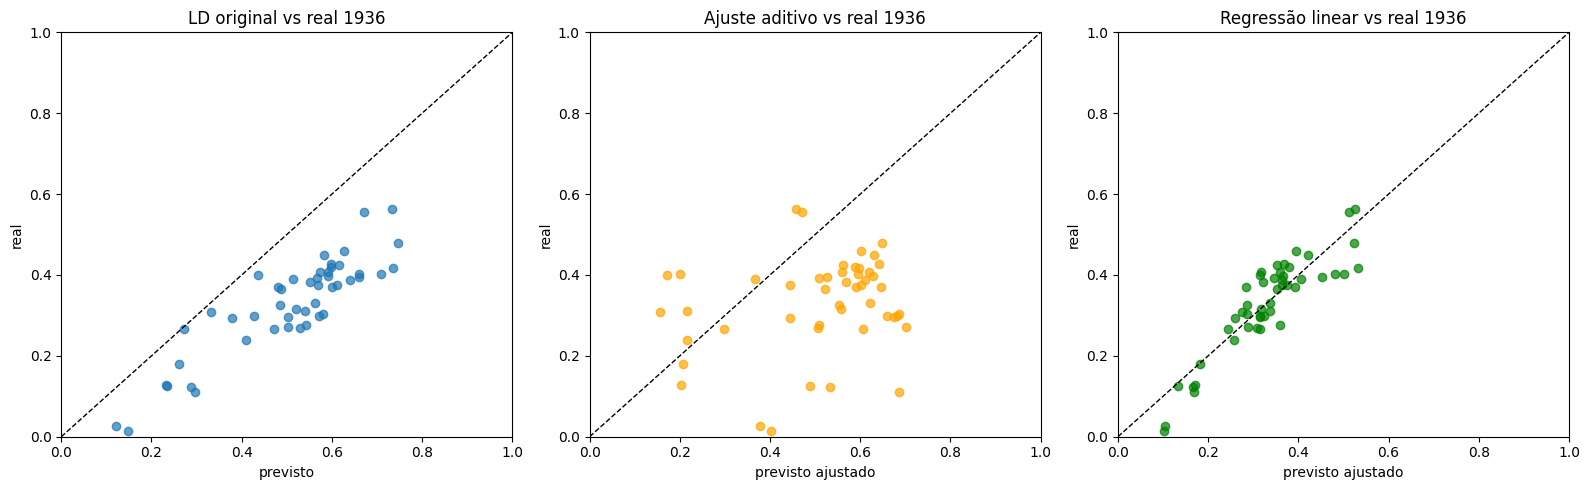

In [ ]:
#cria uma figura com 3 painéis lado a lado para colocar os graficos
fig, ax = plt.subplots(1, 3, figsize=(16, 5))

#Cria os pontos para cada estado e os coloca num grafico baseado na previsão do Literary Digest
ax[0].scatter(cmp["pred_rep_36"], cmp["proporção real 36"], alpha=0.7)

#A linha diagonal representa o resultado perfeito, quanto mais proximo dela melhor a previsão.
ax[0].plot([0, 1], [0, 1], "k--", linewidth=1)

ax[0].set_title("LD original vs real 1936")
ax[0].set_xlabel("previsto")
ax[0].set_ylabel("real")
ax[0].set_xlim(0, 1)
ax[0].set_ylim(0, 1)

#Distribui os dados num grafico baseados no valor corrigido pelo ajuste aditivo
ax[1].scatter(cmp["pred_ajustada_adit"], cmp["proporção real 36"], alpha=0.7, color="orange")
ax[1].plot([0, 1], [0, 1], "k--", linewidth=1)

ax[1].set_title("Ajuste aditivo vs real 1936")
ax[1].set_xlabel("previsto ajustado")
ax[1].set_ylabel("real")
ax[1].set_xlim(0, 1)
ax[1].set_ylim(0, 1)

#Distribui os dados num grafico baseados na implementacao de regressão linear
ax[2].scatter(cmp["previsao regressao"], cmp["proporção real 36"], alpha=0.7, color="green")
ax[2].plot([0, 1], [0, 1], "k--", linewidth=1)

ax[2].set_title("Regressão linear vs real 1936")
ax[2].set_xlabel("previsto ajustado")
ax[2].set_ylabel("real")
ax[2].set_xlim(0, 1)
ax[2].set_ylim(0, 1)

#Display
plt.tight_layout()
plt.show()



Se o ponto estiver na linha tracejada significa que o método acertou. Pontos muito acima da linha significa que o método previu mais voto republicano do que teve, pontos abaixo para democrático.

Como é possível observar nos 2 primeiros gráficos a previão foi bem longe da realidade, onde foram previsto mais pro lado republicano, já no 3 gráfico da regressão linear com os pontos mais próximos da linha mostra uma maior precisão na previsão dos votos.